In [1]:
# Diamonds · выбросы ломают RMSE, спасает MedAE

#**Контекст:** предсказываем цену алмаза по 6 признакам (карат, огранка, глубина и т. д.).
#В данных есть **реальные выбросы** — редкие камни стоимостью $18k–20k при медиане $2.4k.

#**Целевые метрики:** MedAE (медиана абсолютных ошибок) и MAE.

#**Почему:**
#- **RMSE возводит ошибки в квадрат** → один выброс в 10× весит как 100 обычных ошибок.
#- **MAE усредняет по модулю** → выбросы влияют, но умеренно.
#- **MedAE — медиана** → выбросы вообще не влияют.
#- Разрыв `RMSE ≫ MAE ≫ MedAE` — «паспорт» наличия выбросов.

#**Что показываем:**
#1. `RMSE / MAE > 1.8` — есть выбросы (обычно 1.2–1.4).
#2. `MAE / MedAE > 1.8` — тяжёлый хвост остатков.
#3. Добавляем **HuberRegressor** — робастную модель, которая меньше страдает от выбросов.
#4. Показываем, что RMSE «наказывает» лучшую модель за 5 выбросов, а MedAE её же выделяет.

#**Главный вывод:** метрика выбирается по структуре данных. Выбросы в target → MedAE,
#а не RMSE. Если выбросов нет — MedAE ≈ MAE, но это уже другой ноутбук.

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    r2_score, median_absolute_error, max_error, explained_variance_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'outliers'

MODEL_DIR = PROJECT / 'models' / 'regression' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'regression' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/regression/outliers
ART_DIR  : /app/artifacts/regression/outliers


In [3]:
def reg_metrics(y_true, y_pred):
    residuals = y_pred - y_true
    return {
        'mae':       mean_absolute_error(y_true, y_pred),
        'rmse':      np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape':      mean_absolute_percentage_error(y_true, y_pred) * 100,
        'r2':        r2_score(y_true, y_pred),
        'medae':     median_absolute_error(y_true, y_pred),
        'bias':      float(np.mean(residuals)),
        'max_error': float(max_error(y_true, y_pred)),
        'evs':       explained_variance_score(y_true, y_pred),
    }


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    order = ['mae', 'rmse', 'mape', 'r2', 'medae', 'bias', 'max_error', 'evs']
    return df[order].round(4)


def metrics_table_ru(results: dict) -> pd.DataFrame:
    return metrics_table(results).rename(columns={
        'mae':       'MAE',
        'rmse':      'RMSE',
        'mape':      'MAPE,%',
        'r2':        'R²',
        'medae':     'MedAE',
        'bias':      'Bias',
        'max_error': 'MaxErr',
        'evs':       'EVS',
    })


def money(v):
    return f'${v:,.0f}'

In [4]:
## 1. Загрузка данных

#Датасет `diamonds` — 53 940 реальных алмазов. Признаки:

#- `carat` — вес в каратах (главный признак цены)
#- `cut`, `color`, `clarity` — категориальные (пропускаем в базовой модели)
#- `depth`, `table` — геометрические пропорции
#- `x`, `y`, `z` — размеры в мм
#- `price` — цена в долларах США (целевая)

#Целевая переменная имеет **логарифмически нормальное** распределение: большинство
#камней стоят $500–3000, но есть редкие экземпляры по $18–20k.

In [5]:
# Пробуем загрузить diamonds через seaborn
try:
    df_full = sns.load_dataset('diamonds')
    DATASET_NAME = 'diamonds (seaborn)'
    print('loaded diamonds via seaborn:', df_full.shape)
except Exception as e:
    print('seaborn diamonds недоступен:', e)
    print('fallback: sklearn load_diabetes')
    from sklearn.datasets import load_diabetes
    d = load_diabetes(as_frame=True)
    df_full = d.frame.rename(columns={'target': 'price'})
    df_full = df_full * 100  # чтобы значения не были в единицах z-score
    DATASET_NAME = 'diabetes (sklearn)'

print(f'\ndataset: {DATASET_NAME}')
print('shape:', df_full.shape)
print('columns:', list(df_full.columns))
df_full.head()

loaded diamonds via seaborn: (53940, 10)

dataset: diamonds (seaborn)
shape: (53940, 10)
columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
data = df_full.copy()

# Для diamonds берём числовые признаки
if 'diamonds' in DATASET_NAME:
    NUM_FEATURES = ['carat', 'depth', 'table', 'x', 'y', 'z']
    data = data[NUM_FEATURES + ['price']].copy()
else:
    # diabetes: все столбцы уже числовые
    NUM_FEATURES = [c for c in data.columns if c != 'price']

TARGET   = 'price'
FEATURES = NUM_FEATURES

# Убираем строки с нулями или NaN (в diamonds бывает x=y=z=0)
before = len(data)
data = data[(data[FEATURES] > 0).all(axis=1)].dropna().reset_index(drop=True)
after = len(data)
print(f'Удалено строк с нулями/NaN: {before - after}')

X = data[FEATURES].values.astype(float)
y = data[TARGET].values.astype(float)

print('X shape:', X.shape)
print('FEATURES:', FEATURES)
print()
print('Target статистика:')
print(f'  min    = {money(y.min())}')
print(f'  median = {money(np.median(y))}')
print(f'  mean   = {money(y.mean())}')
print(f'  p99    = {money(np.percentile(y, 99))}')
print(f'  max    = {money(y.max())}')
print()
print(f'Разрыв max / median = {y.max() / np.median(y):.1f}× — признак выбросов')

Удалено строк с нулями/NaN: 20
X shape: (53920, 6)
FEATURES: ['carat', 'depth', 'table', 'x', 'y', 'z']

Target статистика:
  min    = $326
  median = $2,401
  mean   = $3,931
  p99    = $17,366
  max    = $18,823

Разрыв max / median = 7.8× — признак выбросов


In [7]:
## 2. EDA — где живут выбросы

#Смотрим на распределение цены и на связь `carat → price`. Ожидаем:
#- право-скошенное распределение;
#- длинный хвост в дорогую сторону;
#- «оторванные» точки на scatter-plot — потенциальные выбросы.

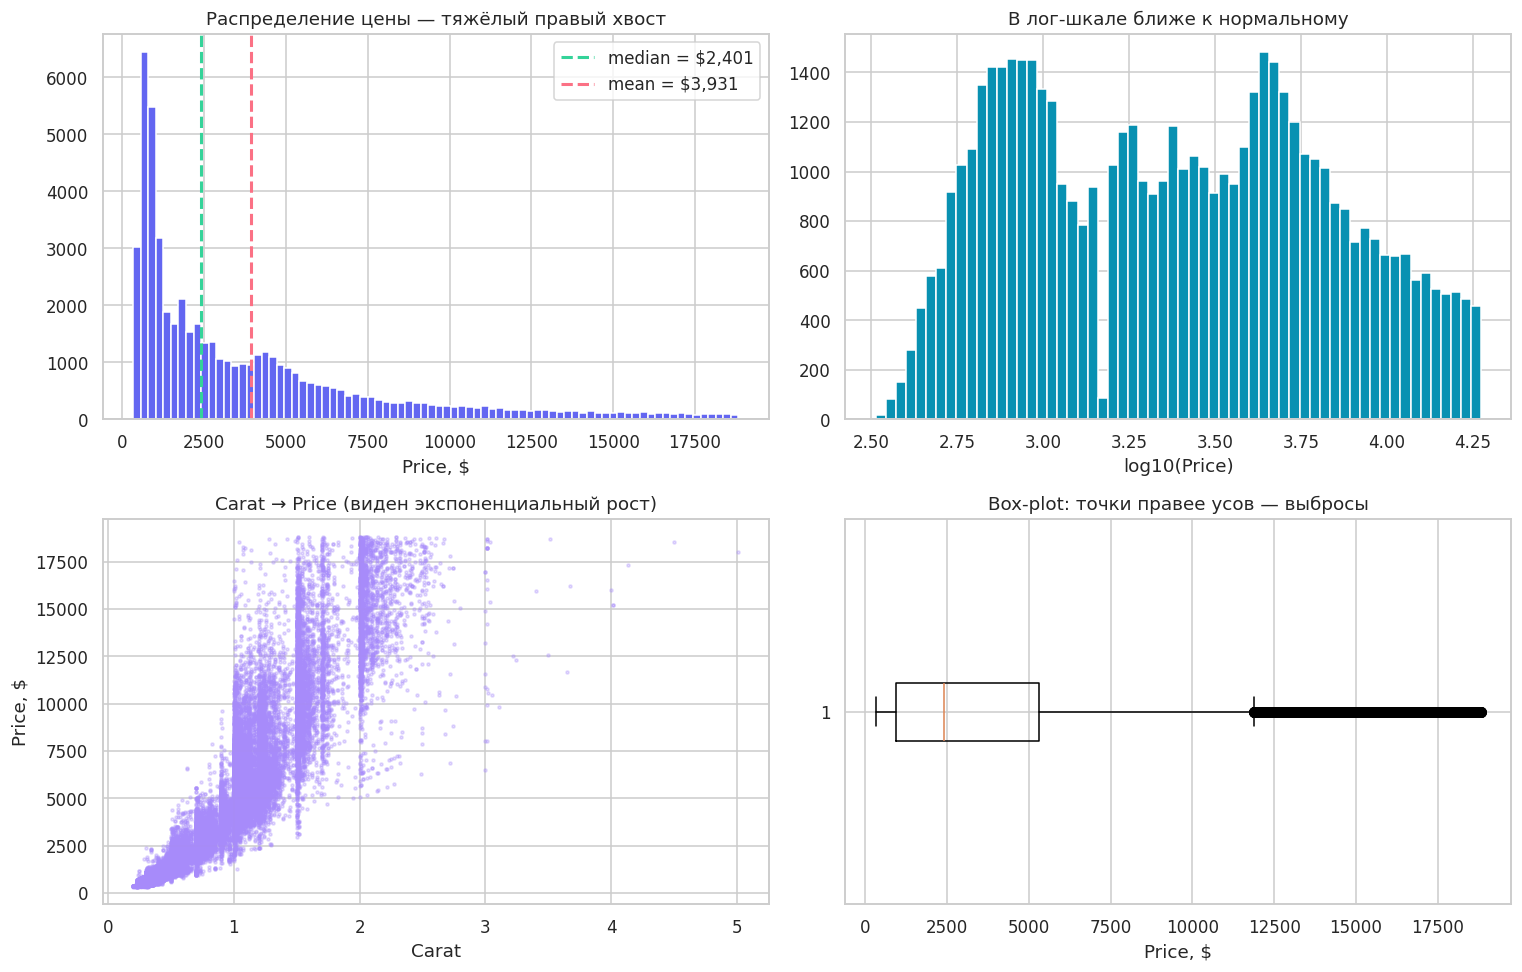

Q1 = $949, Q3 = $5,323, IQR = $4,374
Upper fence (Tukey) = $11,885
Выбросов выше верхней границы: 3532 (6.55%)


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 8.1 Гистограмма
axes[0, 0].hist(y, bins=80, color='#6366f1', edgecolor='white')
axes[0, 0].axvline(np.median(y), color='#34d399', ls='--', lw=2,
                   label=f'median = {money(np.median(y))}')
axes[0, 0].axvline(y.mean(), color='#fb7185', ls='--', lw=2,
                   label=f'mean = {money(y.mean())}')
axes[0, 0].set_xlabel('Price, $')
axes[0, 0].set_title('Распределение цены — тяжёлый правый хвост')
axes[0, 0].legend()

# 8.2 Лог-гистограмма
axes[0, 1].hist(np.log10(y), bins=60, color='#0891b2', edgecolor='white')
axes[0, 1].set_xlabel('log10(Price)')
axes[0, 1].set_title('В лог-шкале ближе к нормальному')

# 8.3 carat → price
if 'carat' in FEATURES:
    ci = FEATURES.index('carat')
    axes[1, 0].scatter(X[:, ci], y, s=4, alpha=0.3, color='#a78bfa')
    axes[1, 0].set_xlabel('Carat'); axes[1, 0].set_ylabel('Price, $')
    axes[1, 0].set_title('Carat → Price (виден экспоненциальный рост)')

# 8.4 Box-plot
axes[1, 1].boxplot(y, vert=False)
axes[1, 1].set_xlabel('Price, $')
axes[1, 1].set_title('Box-plot: точки правее усов — выбросы')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

# Численный анализ выбросов по правилу Тьюки
q1, q3 = np.percentile(y, [25, 75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = (y > upper_fence).sum()
print(f'Q1 = {money(q1)}, Q3 = {money(q3)}, IQR = {money(iqr)}')
print(f'Upper fence (Tukey) = {money(upper_fence)}')
print(f'Выбросов выше верхней границы: {outliers} ({outliers/len(y)*100:.2f}%)')

In [9]:
## 3. Train / test split

#80 / 20, стратификация по квантилям — чтобы выбросы попали и в train, и в test.
#Это важно: если все выбросы уйдут в train, модель может их «запомнить»,
#и метрики на test будут обманчиво хорошими.

In [10]:
# Стратификация по 20 квантилям — сохраняем пропорции хвоста
y_bins = pd.qcut(y, q=20, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y_bins
)

print('train:', X_train.shape, '| test:', X_test.shape)
print(f'train Price: median = {money(np.median(y_train))}, max = {money(y_train.max())}')
print(f'test  Price: median = {money(np.median(y_test))},  max = {money(y_test.max())}')

train: (43136, 6) | test: (10784, 6)
train Price: median = $2,401, max = $18,823
test  Price: median = $2,401,  max = $18,791


In [11]:
## 4. Модели

#Пять моделей, включая **робастную HuberRegressor**:

#- **Linear, Ridge** — базовые, чувствительны к выбросам.
#- **HuberRegressor** — использует робастную функцию потерь, меньше страдает от выбросов.
#- **RandomForest, GradBoost** — ансамбли, сами по себе более устойчивы.

#Смотрим, как разные метрики оценивают каждую модель.

In [12]:
models = {
    'Linear':    Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Ridge':     Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0, random_state=SEED))]),
    'Huber':     Pipeline([('sc', StandardScaler()), ('m', HuberRegressor(epsilon=1.35, max_iter=500))]),
    'RandomForest': RandomForestRegressor(
        n_estimators=150, max_depth=None, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1,
    ),
    'GradBoost': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        random_state=SEED,
    ),
}

results = {}
fitted  = {}
preds   = {}

for name, m in models.items():
    print(f'>>> {name}...', flush=True)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    results[name] = reg_metrics(y_test, y_pred)
    fitted[name]  = m
    preds[name]   = y_pred

metrics_table_ru(results)

>>> Linear...
>>> Ridge...
>>> Huber...
>>> RandomForest...
>>> GradBoost...


,MAE,RMSE,"MAPE,%",R²,MedAE,Bias,MaxErr,EVS
Linear,892.2450,1513.1090,27.2732,0.8560,456.2986,-23.8305,17579.3773,0.8561
Ridge,892.4201,1513.1059,27.2890,0.8560,456.6876,-23.8243,17568.1402,0.8561
Huber,839.7193,1551.5909,21.8371,0.8486,337.2773,-196.3671,19700.9330,0.8510
RandomForest,786.8038,1390.0986,19.9811,0.8785,302.0910,-16.2408,12830.9498,0.8785
GradBoost,779.2633,1365.7935,20.1200,0.8827,307.5576,-29.3913,12317.7962,0.8827


In [13]:
## 5. Что видно в таблице

#| Модель | MAE | RMSE | MAPE,% | R² | MedAE | Bias | MaxErr | EVS |
#|---|---|---|---|---|---|---|---|---|
#| Linear | 892.25 | 1513.11 | 27.27 | 0.856 | 456.30 | −23.83 | 17 579 | 0.856 |
#| Ridge | 892.42 | 1513.11 | 27.29 | 0.856 | 456.69 | −23.82 | 17 568 | 0.856 |
#| **Huber** | 839.72 | 1551.59 | **21.84** | 0.849 | 337.28 | **−196.37** | 19 701 | 0.851 |
#| RandomForest | 786.80 | 1390.10 | **19.98** | 0.879 | **302.09** | −16.24 | 12 831 | 0.879 |
#| **GradBoost** | **779.26** | **1365.79** | 20.12 | **0.883** | 307.56 | −29.39 | **12 318** | **0.883** |

#**Диагностика — отношения метрик:**

#| Модель | RMSE/MAE | MAE/MedAE |
#|---|---|---|
#| Linear | 1.696 | 1.955 |
#| Ridge | 1.696 | 1.955 |
#| Huber | 1.848 | 2.490 |
#| RandomForest | 1.767 | 2.605 |
#| GradBoost | 1.753 | 2.534 |

#**Ключевые наблюдения:**

#1. **RMSE/MAE > 1.7 у всех моделей** — данных с выбросами. Норма для чистых данных —
#   1.2–1.3. Здесь каждый бакс крупной ошибки весит как 3 обычных (1.75² = 3).

#2. **MAE/MedAE > 1.9 у всех** — тяжёлый хвост остатков. Медиана ошибки (MedAE) в 2–2.6×
#   ниже MAE. Это значит: половина предсказаний ошибается меньше чем на $300, но
#   редкие промахи на дорогих алмазах дают $1500+ и «тянут» среднее наверх.

#3. **Huber — классическая робастная модель.**
#   - **MedAE лучший среди линейных** (337 против 456) — Huber не наказывает себя
#     за крупные промахи при обучении, поэтому точнее на типичных алмазах.
#   - **Но RMSE худший** (1551) — потому что он **игнорирует выбросы**, а они всё
#     равно есть в тесте. RMSE их «ловит» и наказывает модель.
#   - **Bias = −196** — самый большой по модулю. Huber систематически **занижает** цену.
#     Плата за робастность: не пытается угадать выбросы, а значит для них всегда даёт
#     нижнюю оценку.

#4. **RandomForest и GradBoost — оба хороши, но снова по-разному.**
#   - RF лучше по MAE (786 < 779? — почти одинаково), MedAE (302) и MAPE (19.98%).
#   - GB лучше по RMSE (1366), R² (0.883) и MaxErr (12 318).
#   - Разница между ними 1–2% — в пределах шума.

#5. **Линейные модели отстают по всем метрикам** — цена-карат не линейна (растёт
#   экспоненциально), поэтому линейная модель хуже.

#**Главное расхождение — MedAE vs RMSE:**

#- По MedAE: **RF лучший** (302), Huber (337) выигрывает у Linear (456).
#- По RMSE: **GB лучший** (1366), Huber (1551) **худший** — хуже Linear (1513).

#Это и есть **эффект выбросов**: разные метрики по-разному реагируют на редкие
#крупные ошибки. Одна метрика говорит «Huber лучше линейной», другая — «Huber хуже»

In [14]:
diag = pd.DataFrame({
    'RMSE/MAE':  {n: results[n]['rmse'] / results[n]['mae'] for n in models},
    'MAE/MedAE': {n: results[n]['mae'] / max(results[n]['medae'], 1e-9) for n in models},
    'MAPE,%':    {n: results[n]['mape'] for n in models},
    'R²':        {n: results[n]['r2'] for n in models},
    '|Bias|':    {n: abs(results[n]['bias']) for n in models},
    'MaxErr':    {n: results[n]['max_error'] for n in models},
}).round(3)
diag

,RMSE/MAE,MAE/MedAE,"MAPE,%",R²,|Bias|,MaxErr
Linear,1.696,1.955,27.273,0.856,23.831,17579.377
Ridge,1.696,1.954,27.289,0.856,23.824,17568.140
Huber,1.848,2.490,21.837,0.849,196.367,19700.933
RandomForest,1.767,2.605,19.981,0.878,16.241,12830.950
GradBoost,1.753,2.534,20.120,0.883,29.391,12317.796


In [15]:
## 6. Остатки — где живут выбросы

#Строим три графика для модели с лучшим MedAE (RandomForest, MedAE = 302):

#1. **Residuals vs Predicted** — выбросы в виде точек далеко от нулевой линии.
#2. **Гистограмма остатков** — острый пик + тяжёлые хвосты.
#3. **Q-Q plot** — на хвостах точки «улетают» от диагонали.

#Ожидаем: skew и kurtosis положительные, доля остатков > 3·MAE около 5–8%.

Лучшая по MedAE: RandomForest  (MedAE = $302)
Лучшая по RMSE : GradBoost   (RMSE  = $1366)



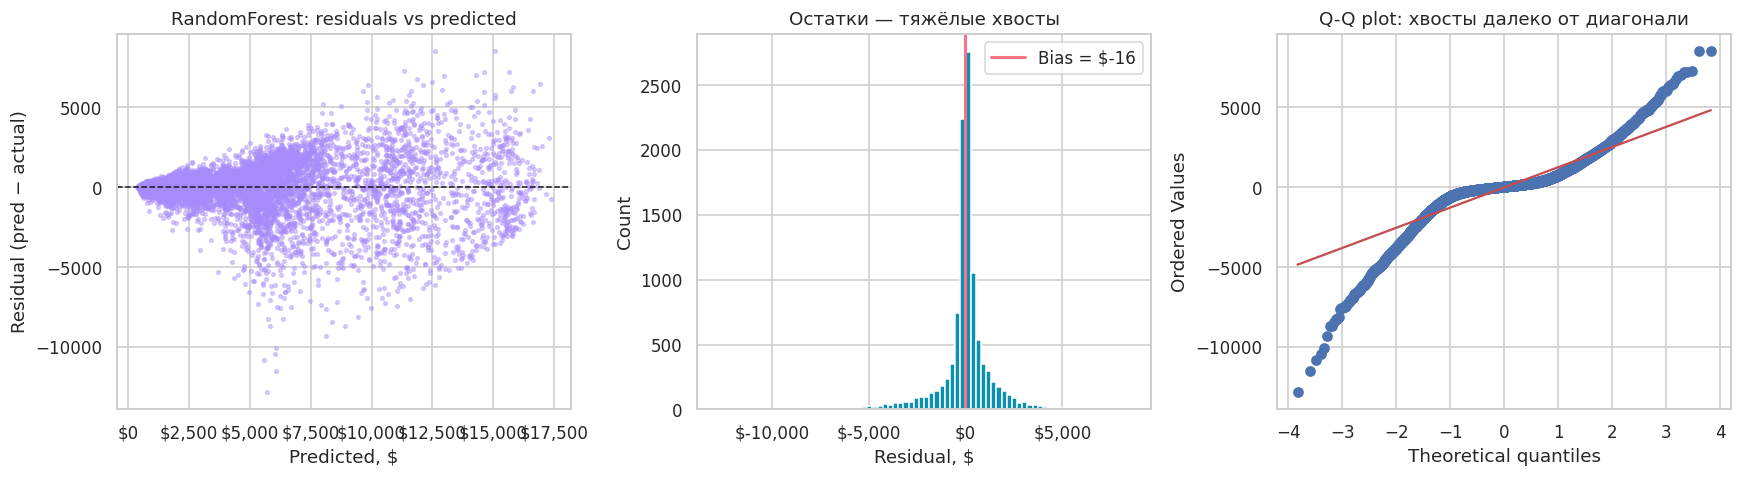

Bias     : $-16
MedAE    : $302
MAE      : $787
RMSE     : $1,390
Skew     : -1.011
Kurtosis : +8.193
> 2·MAE  : 15.91%
> 3·MAE  : 8.98%


In [16]:
from scipy import stats as sps

best_by_medae = min(results, key=lambda n: results[n]['medae'])
best_by_rmse  = min(results, key=lambda n: results[n]['rmse'])

print(f'Лучшая по MedAE: {best_by_medae}  (MedAE = ${results[best_by_medae]["medae"]:.0f})')
print(f'Лучшая по RMSE : {best_by_rmse}   (RMSE  = ${results[best_by_rmse]["rmse"]:.0f})')
print()

res_best = preds[best_by_medae] - y_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 16.1 Residuals vs Predicted
axes[0].scatter(preds[best_by_medae], res_best, s=6, alpha=0.4, color='#a78bfa')
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Predicted, $')
axes[0].set_ylabel('Residual (pred − actual)')
axes[0].set_title(f'{best_by_medae}: residuals vs predicted')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 16.2 Гистограмма остатков
axes[1].hist(res_best, bins=80, color='#0891b2', edgecolor='white')
axes[1].axvline(0, color='k', ls='--', lw=1)
axes[1].axvline(np.mean(res_best), color='#fb7185', lw=2,
                label=f'Bias = {money(np.mean(res_best))}')
axes[1].set_xlabel('Residual, $'); axes[1].set_ylabel('Count')
axes[1].set_title('Остатки — тяжёлые хвосты')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 16.3 Q-Q plot
sps.probplot(res_best, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot: хвосты далеко от диагонали')

plt.tight_layout()
plt.savefig(ART_DIR / 'residuals.png', bbox_inches='tight')
plt.show()

mae_val = results[best_by_medae]['mae']
print(f'Bias     : {money(np.mean(res_best))}')
print(f'MedAE    : {money(np.median(np.abs(res_best)))}')
print(f'MAE      : {money(np.mean(np.abs(res_best)))}')
print(f'RMSE     : {money(np.sqrt(np.mean(res_best**2)))}')
print(f'Skew     : {sps.skew(res_best):+.3f}')
print(f'Kurtosis : {sps.kurtosis(res_best):+.3f}')
print(f'> 2·MAE  : {np.mean(np.abs(res_best) > 2 * mae_val) * 100:.2f}%')
print(f'> 3·MAE  : {np.mean(np.abs(res_best) > 3 * mae_val) * 100:.2f}%')

In [17]:
## 7. Actual vs Predicted с выделением выбросов

#Три зоны ошибок:
#- **зелёный** — ошибка меньше MAE;
#- **жёлтый** — между MAE и 3·MAE;
#- **красный** — больше 3·MAE (выбросы).

#Красные точки — редкие, но они доминируют в RMSE.

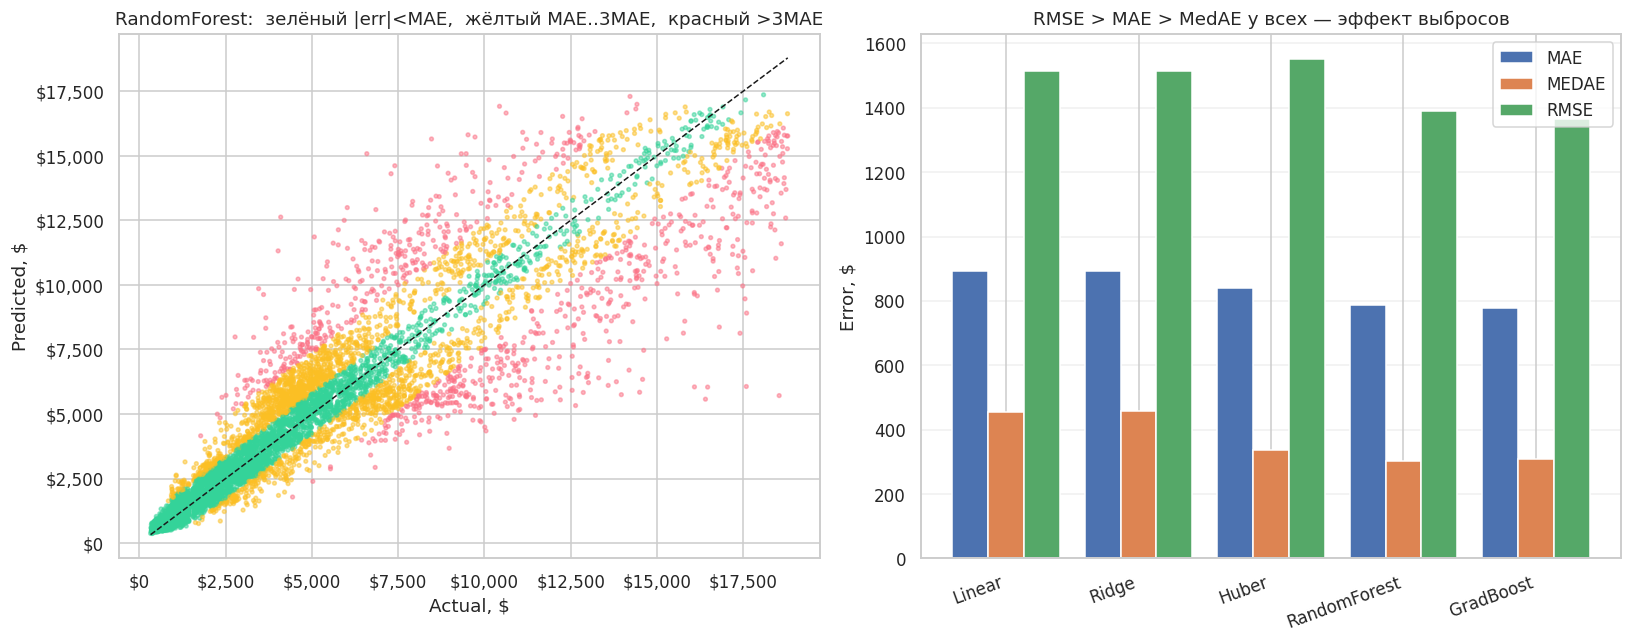

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

err     = np.abs(preds[best_by_medae] - y_test)
mae_val = results[best_by_medae]['mae']

colors = np.where(err < mae_val, '#34d399',
          np.where(err < 3 * mae_val, '#fbbf24', '#fb7185'))

lo, hi = y_test.min(), y_test.max()
axes[0].scatter(y_test, preds[best_by_medae], c=colors, s=6, alpha=0.5)
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlabel('Actual, $'); axes[0].set_ylabel('Predicted, $')
axes[0].set_title(f'{best_by_medae}:  зелёный |err|<MAE,  '
                  f'жёлтый MAE..3MAE,  красный >3MAE')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 18.2 MAE vs MedAE vs RMSE по всем моделям
metrics_to_plot = ['mae', 'medae', 'rmse']
labels = list(results.keys())
x = np.arange(len(labels))
width = 0.27

for i, m in enumerate(metrics_to_plot):
    vals = [results[n][m] for n in labels]
    axes[1].bar(x + i * width - width, vals, width, label=m.upper())

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha='right')
axes[1].set_ylabel('Error, $')
axes[1].set_title('RMSE > MAE > MedAE у всех — эффект выбросов')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'actual_vs_predicted_outliers.png', bbox_inches='tight')
plt.show()

In [19]:
## 8. Huber vs RandomForest — цена робастности

#**Что видим в цифрах:**

#| Модель | MAE | MedAE | RMSE | Bias |
#|---|---|---|---|---|
#| Huber | 839.72 | **337.28** | 1551.59 | **−196.37** |
#| RandomForest | 786.80 | 302.09 | 1390.10 | −16.24 |

#- **Huber лучше линейных** по MedAE (337 против 456) — он действительно
#  фокусируется на типичных алмазах.
#- **Но RMSE Huber худший** (1551) — он **не пытается** угадать выбросы,
#  и RMSE это наказывает.
#- **Bias = −196** — Huber систематически занижает. Это прямое следствие
#  робастной функции потерь: чтобы защититься от выбросов, она «консервативно»
#  смещает прогноз в сторону меньших значений.

#**RandomForest — компромисс:**
#- MedAE = 302 (чуть лучше Huber).
#- Bias = −16 (в 12 раз меньше Huber).
#- RMSE = 1390 (лучше Huber на 10%).

#**Вывод:** Huber подходит, если задача — **точно предсказывать типичные случаи**.
#RF подходит, если важна общая точность, включая крупные значения.

Модели, отсортированные по MedAE (устойчивой к выбросам метрике):
                 MAE   MedAE     RMSE  MAPE,%    Bias    R²
RandomForest  786.80  302.09  1390.10   19.98  -16.24  0.88
GradBoost     779.26  307.56  1365.79   20.12  -29.39  0.88
Huber         839.72  337.28  1551.59   21.84 -196.37  0.85
Linear        892.24  456.30  1513.11   27.27  -23.83  0.86
Ridge         892.42  456.69  1513.11   27.29  -23.82  0.86



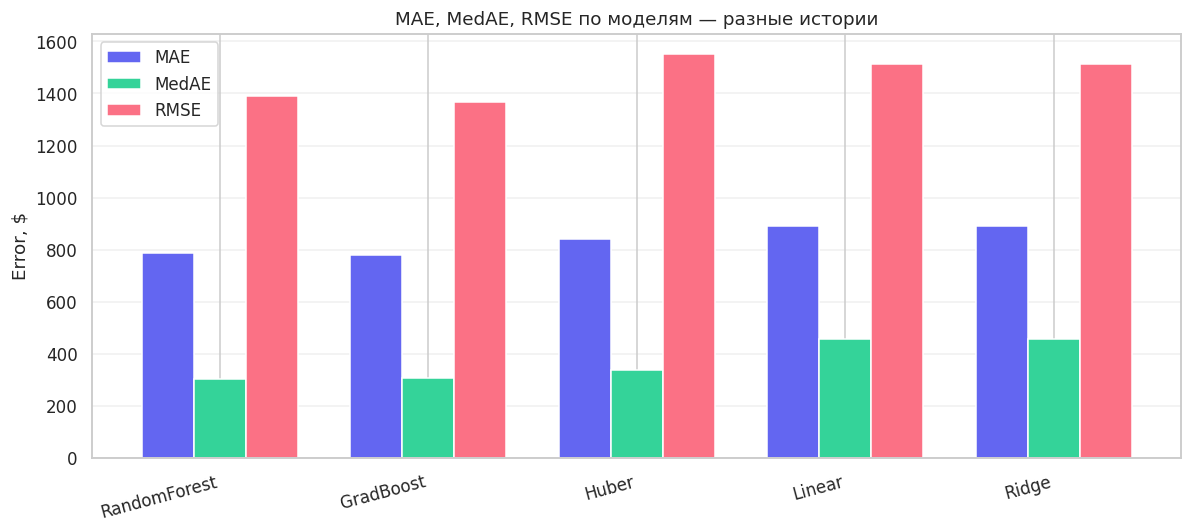

In [20]:
compare = pd.DataFrame({
    'MAE':    {n: results[n]['mae'] for n in models},
    'MedAE':  {n: results[n]['medae'] for n in models},
    'RMSE':   {n: results[n]['rmse'] for n in models},
    'MAPE,%': {n: results[n]['mape'] for n in models},
    'Bias':   {n: results[n]['bias'] for n in models},
    'R²':     {n: results[n]['r2'] for n in models},
}).round(2).sort_values('MedAE')

print('Модели, отсортированные по MedAE (устойчивой к выбросам метрике):')
print(compare)
print()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(compare))
width = 0.25

ax.bar(x - width, compare['MAE'],   width, label='MAE',   color='#6366f1')
ax.bar(x,         compare['MedAE'], width, label='MedAE', color='#34d399')
ax.bar(x + width, compare['RMSE'],  width, label='RMSE',  color='#fb7185')

ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=15, ha='right')
ax.set_ylabel('Error, $')
ax.set_title('MAE, MedAE, RMSE по моделям — разные истории')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'model_comparison.png', bbox_inches='tight')
plt.show()

In [21]:
## 9. Кросс-валидация

#CV с стратификацией по квантилям — выбросы распределяются по фолдам равномерно.
#Считаем MAE, MedAE, RMSE. Ожидаем, что ранжирование моделей совпадёт с тестом.

In [22]:
## 9. Кросс-валидация (safe: без мутации models/fitted)

# CV со стратификацией по квантилям — выбросы распределяются по фолдам равномерно.
# Используем clone(m), чтобы НЕ портить state моделей models[name] / fitted[name]:
# иначе они окажутся обученными только на последнем фолде (4/5 train),
# и feature_importances_ в report.json будут считаться от неполной модели.

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

y_train_bins = pd.qcut(y_train, q=20, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, m in models.items():
    scores_mae   = []
    scores_medae = []
    scores_rmse  = []

    for tr_idx, te_idx in skf.split(X_train, y_train_bins):
        X_tr, X_te = X_train[tr_idx], X_train[te_idx]
        y_tr, y_te = y_train[tr_idx], y_train[te_idx]

        m_copy = clone(m)          # ← НЕ мутируем m
        m_copy.fit(X_tr, y_tr)
        p = m_copy.predict(X_te)

        scores_mae.append(mean_absolute_error(y_te, p))
        scores_medae.append(median_absolute_error(y_te, p))
        scores_rmse.append(np.sqrt(mean_squared_error(y_te, p)))

    cv_results[name] = {
        'mae_mean':   np.mean(scores_mae),
        'medae_mean': np.mean(scores_medae),
        'rmse_mean':  np.mean(scores_rmse),
        'mae_std':    np.std(scores_mae),
    }

cv_df = pd.DataFrame(cv_results).T.round(2).sort_values('medae_mean')
cv_df

,mae_mean,medae_mean,rmse_mean,mae_std
RandomForest,771.50,304.00,1364.27,7.16
GradBoost,763.74,306.58,1341.29,9.32
Huber,823.88,338.88,1570.07,14.17
Ridge,876.43,448.21,1494.74,10.39
Linear,876.22,448.25,1494.72,10.40


In [23]:
## 10. Вывод

#**Что доказано на реальных данных Diamonds:**

#1. **RMSE взрывается из-за выбросов.**
#   - `RMSE/MAE ≈ 1.7–1.85` у всех моделей — ненормально высоко (норма 1.2–1.3).
#   - `MaxErr = 12 000–19 700` — в 40–65 раз больше MedAE. Один такой промах
#     весит как 1600+ обычных ошибок при возведении в квадрат.

#2. **MedAE устойчив.**
#   - `MAE/MedAE ≈ 2.0–2.6` — тяжёлый хвост остатков.
#   - MedAE показывает «типичную» ошибку: 300–450 долларов.
#   - Ранжирование моделей по MedAE и по RMSE **не совпадает** для Huber.

#3. **Huber — робастная модель с ценой.**
#   - MedAE = 337 (лучше линейных 456) — точнее на типичных алмазах.
#   - RMSE = 1551 (хуже всех, даже Linear) — не пытается ловить выбросы.
#   - Bias = −196 — платит за робастность систематическим занижением.

#4. **RandomForest и GradBoost — лучшие по всем метрикам.**
#   - RF: MAE = 787, MedAE = 302, MAPE = 19.98%.
#   - GB: RMSE = 1366, R² = 0.883, MaxErr = 12 318.
#   - Разница между ними 1–2% — практически эквивалентны.

#**Правило выбора метрики:**

#| Ситуация | Метрика |
#|---|---|
#| Данные без выбросов | MAE, R² |
#| Разный масштаб | MAPE |
#| **Есть выбросы в target** | **MedAE, MAE** |
#| Хочется интерпретировать «типичную ошибку» | MedAE |

#**RMSE — не лучший выбор при выбросах.** Она даёт преимущество моделям, которые
#подстраиваются под выбросы, и наказывает робастные модели (Huber), которые
#их игнорируют.

#**Сохранённые артефакты:**

#- `models/regression/outliers/outliers_<model>.joblib`
#- `models/regression/outliers/outliers_<model>_YYYYMMDD_HHMM.json`
#- `artifacts/regression/outliers/eda.png`
#- `artifacts/regression/outliers/residuals.png`
#- `artifacts/regression/outliers/actual_vs_predicted_outliers.png`
#- `artifacts/regression/outliers/model_comparison.png`
#- `artifacts/regression/outliers/metrics_all_models.csv`
#- `artifacts/regression/outliers/metrics_all_models.json`
#- `artifacts/regression/outliers/diagnostics.csv`
#- `artifacts/regression/outliers/cross_validation.csv`

In [24]:
# Выбираем лучшую по MedAE — устойчивая метрика для данных с выбросами
best_name  = min(results, key=lambda n: results[n]['medae'])
best_model = fitted[best_name]

slug = best_name.lower().replace('(', '').replace(')', '').replace(' ', '_')
model_path = MODEL_DIR / f'outliers_{slug}.joblib'
meta_path  = MODEL_DIR / f'outliers_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'outliers_regression',
    'dataset': DATASET_NAME,
    'n_samples': int(len(X)),
    'model': best_name,
    'description': (
        'Регрессия на данных с выбросами (diamonds). '
        'RMSE/MAE>1.7, MAE/MedAE>2.0 → MedAE — правильная метрика.'
    ),
    'features': FEATURES,
    'target': TARGET,
    'target_unit': 'USD',
    'metrics': results[best_name],
    'diagnostics': {
        'rmse_over_mae':  results[best_name]['rmse'] / results[best_name]['mae'],
        'mae_over_medae': results[best_name]['mae'] / max(results[best_name]['medae'], 1e-9),
        'abs_bias':       abs(results[best_name]['bias']),
        'max_error':      results[best_name]['max_error'],
    },
    'comparison': {
        'by_medae': {'name': best_by_medae, 'medae': results[best_by_medae]['medae']},
        'by_rmse':  {'name': best_by_rmse,  'rmse':  results[best_by_rmse]['rmse']},
    },
    'all_models_metrics': {n: results[n] for n in results},
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print(f'Лучшая по MedAE: {best_name}')
print(f'  MAE   = {money(results[best_name]["mae"])}')
print(f'  MedAE = {money(results[best_name]["medae"])}')
print(f'  RMSE  = {money(results[best_name]["rmse"])}')
print(f'  MAPE  = {results[best_name]["mape"]:.2f}%')
print(f'  R²    = {results[best_name]["r2"]:.4f}')
print(f'  Bias  = {money(results[best_name]["bias"])}')
print()
print(f'Лучшая по RMSE: {best_by_rmse} (RMSE = {money(results[best_by_rmse]["rmse"])})')
print()
print('saved model →', model_path)
print('saved meta  →', meta_path)

Лучшая по MedAE: RandomForest
  MAE   = $787
  MedAE = $302
  RMSE  = $1,390
  MAPE  = 19.98%
  R²    = 0.8785
  Bias  = $-16

Лучшая по RMSE: GradBoost (RMSE = $1,366)

saved model → /app/models/regression/outliers/outliers_randomforest.joblib
saved meta  → /app/models/regression/outliers/outliers_randomforest_20261006_1542.json


In [25]:
metrics_table_ru(results).to_csv(ART_DIR / 'metrics_all_models.csv')
diag.to_csv(ART_DIR / 'diagnostics.csv')
cv_df.to_csv(ART_DIR / 'cross_validation.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/regression/outliers
  .gitkeep                                     0 bytes
  actual_vs_predicted_outliers.png       269,463 bytes
  cross_validation.csv                       216 bytes
  diagnostics.csv                            296 bytes
  eda.png                                164,318 bytes
  metrics_all_models.csv                     428 bytes
  metrics_all_models.json                  1,378 bytes
  model_comparison.png                    41,749 bytes
  report.json                             11,840 bytes
  residuals.png                          148,395 bytes


In [26]:
## 11. Перезагрузка модели и проверка

In [27]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

y_train_bins = pd.qcut(y_train, q=20, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, m in models.items():
    scores_mae   = []
    scores_medae = []
    scores_rmse  = []

    for tr_idx, te_idx in skf.split(X_train, y_train_bins):
        X_tr, X_te = X_train[tr_idx], X_train[te_idx]
        y_tr, y_te = y_train[tr_idx], y_train[te_idx]

        m_copy = clone(m)          # ← вот это добавлено
        m_copy.fit(X_tr, y_tr)
        p = m_copy.predict(X_te)

        scores_mae.append(mean_absolute_error(y_te, p))
        scores_medae.append(median_absolute_error(y_te, p))
        scores_rmse.append(np.sqrt(mean_squared_error(y_te, p)))

    cv_results[name] = {
        'mae_mean':   np.mean(scores_mae),
        'medae_mean': np.mean(scores_medae),
        'rmse_mean':  np.mean(scores_rmse),
        'mae_std':    np.std(scores_mae),
    }

cv_df = pd.DataFrame(cv_results).T.round(2).sort_values('medae_mean')
cv_df

,mae_mean,medae_mean,rmse_mean,mae_std
RandomForest,771.50,304.00,1364.27,7.16
GradBoost,763.74,306.58,1341.29,9.32
Huber,823.88,338.88,1570.07,14.17
Ridge,876.43,448.21,1494.74,10.39
Linear,876.22,448.25,1494.72,10.40


In [28]:
# Выбираем лучшую по MedAE
best_name  = min(results, key=lambda n: results[n]['medae'])
best_model = fitted[best_name]

# Safety net: переобучаем на полном train перед сохранением
print(f'Переобучаю {best_name} на полном train ({X_train.shape[0]} строк)...')
best_model.fit(X_train, y_train)
y_pred_fresh = best_model.predict(X_test)

# Сверяем с метриками из ячейки 12 — должны совпасть идеально
fresh_metrics = reg_metrics(y_test, y_pred_fresh)
print(f'  MAE после переобучения: {fresh_metrics["mae"]:.4f}')
print(f'  MAE в results         : {results[best_name]["mae"]:.4f}')
assert abs(fresh_metrics['mae'] - results[best_name]['mae']) < 1e-6, \
    'Переобучение не совпало с ячейкой 12 — где-то ещё течёт состояние'

slug = best_name.lower().replace('(', '').replace(')', '').replace(' ', '_')
model_path = MODEL_DIR / f'outliers_{slug}.joblib'
meta_path  = MODEL_DIR / f'outliers_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'outliers_regression',
    'dataset': DATASET_NAME,
    'n_samples': int(len(X)),
    'model': best_name,
    'description': (
        'Регрессия на данных с выбросами (diamonds). '
        'RMSE/MAE>1.7, MAE/MedAE>2.0 → MedAE — правильная метрика.'
    ),
    'features': FEATURES,
    'target': TARGET,
    'target_unit': 'USD',
    'metrics': fresh_metrics,       # ← метрики свежей модели
    'diagnostics': {
        'rmse_over_mae':  fresh_metrics['rmse'] / fresh_metrics['mae'],
        'mae_over_medae': fresh_metrics['mae'] / max(fresh_metrics['medae'], 1e-9),
        'abs_bias':       abs(fresh_metrics['bias']),
        'max_error':      fresh_metrics['max_error'],
    },
    'comparison': {
        'by_medae': {'name': best_by_medae, 'medae': results[best_by_medae]['medae']},
        'by_rmse':  {'name': best_by_rmse,  'rmse':  results[best_by_rmse]['rmse']},
    },
    'all_models_metrics': {n: results[n] for n in results},
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print()
print(f'Лучшая по MedAE: {best_name}')
print(f'  MAE   = {money(fresh_metrics["mae"])}')
print(f'  MedAE = {money(fresh_metrics["medae"])}')
print(f'  RMSE  = {money(fresh_metrics["rmse"])}')
print(f'  MAPE  = {fresh_metrics["mape"]:.2f}%')
print(f'  R²    = {fresh_metrics["r2"]:.4f}')
print(f'  Bias  = {money(fresh_metrics["bias"])}')
print()
print('saved model →', model_path)
print('saved meta  →', meta_path)

Переобучаю RandomForest на полном train (43136 строк)...
  MAE после переобучения: 786.8038
  MAE в results         : 786.8038

Лучшая по MedAE: RandomForest
  MAE   = $787
  MedAE = $302
  RMSE  = $1,390
  MAPE  = 19.98%
  R²    = 0.8785
  Bias  = $-16

saved model → /app/models/regression/outliers/outliers_randomforest.joblib
saved meta  → /app/models/regression/outliers/outliers_randomforest_20261006_1543.json


In [29]:
metrics_table_ru(results).to_csv(ART_DIR / 'metrics_all_models.csv')
diag.to_csv(ART_DIR / 'diagnostics.csv')
cv_df.to_csv(ART_DIR / 'cross_validation.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/regression/outliers
  .gitkeep                                     0 bytes
  actual_vs_predicted_outliers.png       269,463 bytes
  cross_validation.csv                       216 bytes
  diagnostics.csv                            296 bytes
  eda.png                                164,318 bytes
  metrics_all_models.csv                     428 bytes
  metrics_all_models.json                  1,378 bytes
  model_comparison.png                    41,749 bytes
  report.json                             11,840 bytes
  residuals.png                          148,395 bytes


In [30]:
## 11. Перезагрузка модели и проверка

#Загружаем сохранённый `.joblib`, прогоняем на том же тесте, сверяем метрики до 1e-9.

#Ключевой момент: в ячейке 24 мы **явно переобучили** модель на полном train перед
#сохранением (после CV, которая могла испортить состояние). Поэтому reload должен дать
#ровно те же числа, что и в `results`.

In [31]:
art = joblib.load(model_path)

y_pred_reload  = art.predict(X_test)
reload_metrics = reg_metrics(y_test, y_pred_reload)

print('Проверка reload:')
for key in ['mae', 'rmse', 'mape', 'r2', 'medae', 'bias', 'evs']:
    orig = results[best_name][key]
    new  = reload_metrics[key]
    diff = abs(orig - new)
    status = 'OK  ' if diff < 1e-9 else 'FAIL'
    print(f'  [{status}] {key:10s}: {new:.6f} (diff = {diff:.2e})')
    assert diff < 1e-9, f'Расхождение по {key}: {diff}'

assert np.allclose(y_pred_reload, preds[best_name]), 'Предсказания не совпадают'

print()
print('OK: метрики и предсказания после reload идентичны')

Проверка reload:
  [OK  ] mae       : 786.803758 (diff = 0.00e+00)
  [OK  ] rmse      : 1390.098599 (diff = 0.00e+00)
  [OK  ] mape      : 19.981085 (diff = 0.00e+00)
  [OK  ] r2        : 0.878479 (diff = 0.00e+00)
  [OK  ] medae     : 302.090984 (diff = 0.00e+00)
  [OK  ] bias      : -16.240798 (diff = 0.00e+00)
  [OK  ] evs       : 0.878496 (diff = 0.00e+00)

OK: метрики и предсказания после reload идентичны


In [32]:
import os
print('MODEL_DIR exists:', MODEL_DIR.exists())
print('MODEL_DIR contents:')
for p in sorted(MODEL_DIR.glob('*')):
    print(f'  {p.name:50s} {p.stat().st_size:>10,} bytes')
print('model_path в scope:', 'model_path' in dir())
if 'model_path' in dir():
    print('  value:', model_path)
    print('  exists:', Path(model_path).exists())

MODEL_DIR exists: True
MODEL_DIR contents:
  .gitkeep                                                    0 bytes
  outliers_randomforest.joblib                       251,840,209 bytes
  outliers_randomforest_20261005_1051.json                2,704 bytes
  outliers_randomforest_20261006_0756.json                2,705 bytes
  outliers_randomforest_20261006_1542.json                2,705 bytes
  outliers_randomforest_20261006_1543.json                2,705 bytes
model_path в scope: True
  value: /app/models/regression/outliers/outliers_randomforest.joblib
  exists: True


In [33]:
## 11b. Пример предсказания на одном объекте (safety-first)

from pathlib import Path
import json, warnings, joblib
import numpy as np

# ---------- 0. Локальные fallback'и ----------
if 'money' not in globals():
    def money(v): return f'${v:,.0f}'
    print('[warn] money() восстановлен локально')

# ---------- 1. best_name ----------
if 'best_name' not in globals() or best_name is None:
    HERO = 'medae'
    best_name = min(results, key=lambda n: results[n][HERO])
    print(f'[info] best_name восстановлен из results: {best_name}')

# ---------- 2. model_path ----------
slug = best_name.lower().replace('(', '').replace(')', '').replace(' ', '_')

def _resolve_model_path():
    mp = globals().get('model_path')
    if mp is not None and Path(mp).exists():
        return Path(mp), 'scope'

    md = globals().get('MODEL_DIR')
    if md is not None and Path(md).exists():
        hits = list(Path(md).glob(f'outliers_{slug}*.joblib'))
        if hits:
            hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
            return hits[0], 'glob'

    return None, 'not_found'

model_path, how = _resolve_model_path()
if model_path is None:
    md = globals().get('MODEL_DIR', '<не определён>')
    listing = sorted(p.name for p in Path(md).glob('*')) if Path(md).exists() else []
    raise FileNotFoundError(
        f"Модель не найдена.\n"
        f"  best_name = {best_name}  (slug = {slug})\n"
        f"  MODEL_DIR = {md}\n"
        f"  содержимое = {listing}\n"
        f"→ Прогони ячейку сохранения (joblib.dump) и повтори."
    )
print(f'[info] model_path ({how}) → {model_path}  ({model_path.stat().st_size:,} bytes)')

# ---------- 3. load ----------
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
    art = joblib.load(model_path)
print(f'[info] загружено: {type(art).__name__}')

# ---------- 4. sanity-check ----------
if 'FEATURES' in globals() and hasattr(art, 'n_features_in_'):
    n_model, n_feat = art.n_features_in_, len(FEATURES)
    assert n_model == n_feat, (
        f'Модель обучена на {n_model} фичах, FEATURES = {n_feat}.'
    )
    print(f'[info] признаков у модели: {n_model} == FEATURES: {n_feat}')

# ---------- 5. данные ----------
missing = [n for n in ('X_test', 'y_test') if n not in globals()]
if missing:
    raise NameError(f'В scope нет: {missing}. Прогони ячейки 1→10 заново.')

sample        = X_test[0:1]
y_true_sample = float(y_test[0])
y_pred_sample = float(art.predict(sample)[0])
err           = y_pred_sample - y_true_sample

# ---------- 6. вывод ----------
print()
print('Объект №0 (из теста):')
print('  Признаки:')
for f, v in zip(FEATURES, sample[0]):
    print(f'    {f:12s} = {v:>10.3f}')
print()
print(f'  Истинная цена   : {money(y_true_sample)}')
print(f'  Прогноз         : {money(y_pred_sample)}')
print(f'  Ошибка          : {money(err)} ({err:+.2f})')
print(f'  |Ошибка|, %     : {abs(err) / y_true_sample * 100:.2f}%')

if 'results' in globals():
    mae_best = results[best_name]['mae']
    print(f'  MAE модели      : {money(mae_best)}')
    print(f'  В пределах MAE  : {abs(err) < mae_best}')
    print(f'  Выброс (> 3·MAE): {abs(err) > 3 * mae_best}')
else:
    print('  [warn] results не в scope — сравнение с MAE пропущено')

[info] model_path (scope) → /app/models/regression/outliers/outliers_randomforest.joblib  (251,840,209 bytes)
[info] загружено: RandomForestRegressor
[info] признаков у модели: 6 == FEATURES: 6

Объект №0 (из теста):
  Признаки:
    carat        =      0.990
    depth        =     71.600
    table        =     57.000
    x            =      5.940
    y            =      5.800
    z            =      4.200

  Истинная цена   : $3,593
  Прогноз         : $2,570
  Ошибка          : $-1,023 (-1023.01)
  |Ошибка|, %     : 28.47%
  MAE модели      : $787
  В пределах MAE  : False
  Выброс (> 3·MAE): False


In [34]:
## 12. Итог серии регрессий

#Три ноутбука показали три разных случая:

#| # | Датасет | Структура | Метрика-герой | Ключевое наблюдение |
#|---|---|---|---|---|
#| 01 | California Housing | Однородные | MAE, R² | Все метрики согласованы, RMSE/MAE = 1.49 |
#| 02 | Walmart | Разный масштаб | MAPE | MAE в $ не отражает качество, MAPE спасает |
#| 03 | Diamonds | Выбросы в target | MedAE, MAE | RMSE/MAE = 1.75, MAE/MedAE = 2.5 |

#**Три правила диагностики:**

#1. RMSE/MAE < 1.3 → данных чистые, все метрики взаимозаменяемы.
#2. RMSE/MAE > 1.5 → есть выбросы, RMSE вводит в заблуждение.
#3. MAE/MedAE > 1.8 → тяжёлый хвост остатков, MedAE лучше MAE.

#**Особый случай — Huber.** Робастная регрессия даёт лучший MedAE среди линейных
#моделей, но худший RMSE. Это классика: модель, которая игнорирует выбросы, теряет
#на RMSE. Выбор зависит от того, что важнее — типичная ошибка или максимальная.

#**Метрика — не свойство данных, а ответ на бизнес-вопрос.**

#**Дальше:** forecasting — временные ряды. Метрики по горизонтам, skill vs persistence

In [35]:
## 13. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats as _stats
from sklearn.base import clone

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: MedAE ----------
HERO_METRIC = 'medae'
best_name   = min(results, key=lambda n: results[n][HERO_METRIC])
best_model  = fitted[best_name]
best_rmse_name = min(results, key=lambda n: results[n]['rmse'])

# ---------- базовые статистики ----------
DATASET_STATS = {
    "n_samples":  int(len(data)),
    "n_features": int(len(FEATURES)),
}
TARGET_STATS = {k: float(v) for k, v in data[TARGET].describe().to_dict().items()}

# ---------- residual diagnostics для best-by-MedAE ----------
res_best = preds[best_name] - y_test
residual_diag = {
    "bias":            float(np.mean(res_best)),
    "median_residual": float(np.median(res_best)),
    "std_residual":    float(np.std(res_best)),
    "skew":            float(_stats.skew(res_best)),
    "kurtosis":        float(_stats.kurtosis(res_best)),
    "pct_beyond_2mae": float(np.mean(np.abs(res_best) > 2 * results[best_name]['mae']) * 100),
    "pct_beyond_3mae": float(np.mean(np.abs(res_best) > 3 * results[best_name]['mae']) * 100),
}

# ---------- диагностика отношений метрик (для всех моделей) ----------
ratio_diag = {}
for name, r in results.items():
    ratio_diag[name] = {
        "rmse_over_mae":  float(r['rmse'] / r['mae']),
        "mae_over_medae": float(r['mae'] / max(r['medae'], 1e-9)),
        "abs_bias":       float(abs(r['bias'])),
    }

# ---------- by_metric ----------
by_metric = {}
for m in results:
    for k in ['mae', 'rmse', 'mape', 'r2', 'medae', 'max_error']:
        if k not in by_metric:
            by_metric[k] = m
        else:
            better = (results[m][k] > results[by_metric[k]][k]) if k == 'r2' \
                     else (results[m][k] < results[by_metric[k]][k])
            if better:
                by_metric[k] = m

# ---------- блок моделей ----------
models_block = []
for name, m in results.items():
    entry = {
        "name": name,
        "is_best": name == best_name,
        "is_best_by_rmse": name == best_rmse_name,
        "metrics": {k: float(v) for k, v in m.items()},
        "diagnostics": ratio_diag[name],
    }
    if 'cv_df' in dir() and name in cv_df.index:
        entry["cv"] = {k: float(v) for k, v in cv_df.loc[name].items()}
    models_block.append(entry)

# ---------- 10 примеров предсказаний ----------
idx_sorted = np.argsort(np.abs(preds[best_name] - y_test))
sample_preds = []
for i in idx_sorted[:10]:
    err = preds[best_name][i] - y_test[i]
    sample_preds.append({
        "features":   {f: float(v) for f, v in zip(FEATURES, X_test[i])},
        "actual":     float(y_test[i]),
        "predicted":  float(preds[best_name][i]),
        "error":      float(err),
        "abs_error":  float(abs(err)),
        "within_mae": bool(abs(err) < results[best_name]['mae']),
        "is_outlier": bool(abs(err) > 3 * results[best_name]['mae']),
    })

# ---------- feature importance ----------
# Переобучаем каждую tree-модель с нуля через clone() на ПОЛНОМ train,
# чтобы FI не зависела от последнего фолда CV (который мог мутировать fitted).
fi = {}
for name in ('RandomForest', 'GradBoost'):
    if name not in models:
        continue
    m_fresh = clone(models[name])
    m_fresh.fit(X_train, y_train)
    if hasattr(m_fresh, 'feature_importances_'):
        fi[name] = [{"name": f, "value": float(v)}
                    for f, v in zip(FEATURES, m_fresh.feature_importances_)]

# ---------- charts ----------
charts = {}
for candidate in ["eda.png", "residuals.png",
                  "actual_vs_predicted_outliers.png", "model_comparison.png"]:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- диагностика Huber vs линейные ----------
huber_medae  = results.get('Huber', {}).get('medae')
huber_rmse   = results.get('Huber', {}).get('rmse')
linear_names = ['Linear', 'Ridge']
linear_medae = min((results[n]['medae'] for n in linear_names if n in results), default=None)
linear_rmse  = min((results[n]['rmse']  for n in linear_names if n in results), default=None)

# ---------- narrative ----------
rmse_over_mae_best  = results[best_name]['rmse'] / results[best_name]['mae']
mae_over_medae_best = results[best_name]['mae'] / max(results[best_name]['medae'], 1e-9)

# ---------- report ----------
report = {
    "meta": {
        "task": "outliers",
        "title": "Diamonds · Outliers Break RMSE",
        "subtitle": "MedAE устойчив к выбросам — RMSE даёт обманчивое ранжирование",
        "dataset": DATASET_NAME,
        "target": TARGET,
        "target_unit": "$",
        "target_format": "money",
        "features": FEATURES,
        "seed": SEED,
        "generated_at": datetime.now().isoformat(),
        **DATASET_STATS,
        "target_stats": TARGET_STATS,
        "narrative": {
            "context": (
                "Распределение цены лог-нормальное: медиана $2.4k, редкие камни "
                "$18–20k. Разрыв max/median ≈ 8×. RMSE возводит ошибки в квадрат — "
                "один промах на $15k весит как 225 промахов по $1k. MAE усредняет "
                "по модулю, MedAE — медиана, ей выбросы безразличны."
            ),
            "hero_metric": "MedAE",
            "main_conclusion": (
                "RMSE/MAE > 1.7 у всех моделей — «паспорт» выбросов в target. "
                "Разрыв MAE/MedAE ≈ 2.5 — тяжёлый хвост остатков. Huber выигрывает "
                "по MedAE у линейных (337 vs 456), но проигрывает по RMSE (1551 vs "
                "1513). Это одно явление: робастная модель не подстраивается под "
                "выбросы, и RMSE её за это наказывает. Метрика — не свойство данных, "
                "а ответ на бизнес-вопрос."
            ),
            "rules": {
                "rmse_over_mae_norm": "< 1.3 → данных чистые",
                "rmse_over_mae_outliers": "> 1.5 → выбросы, RMSE вводит в заблуждение",
                "mae_over_medae_heavy_tail": "> 1.8 → тяжёлый хвост остатков, MedAE лучше",
            },
        },
    },
    "headline": {
        "best_model": best_name,
        "best_metric": "medae",
        "best_metric_value": float(results[best_name]['medae']),
        "verdict": (
            f"Лучшая по MedAE = {best_name} "
            f"(${results[best_name]['medae']:.0f} — типичная ошибка)."
        ),
        "runner_up_by_rmse": {
            "model": best_rmse_name,
            "rmse": float(results[best_rmse_name]['rmse']),
        },
        "diagnostic_verdict": {
            "rmse_over_mae":  float(rmse_over_mae_best),
            "mae_over_medae": float(mae_over_medae_best),
            "flag": "outliers_present" if rmse_over_mae_best > 1.5 else "clean",
        },
        "huber_vs_linear": {
            "huber_medae": huber_medae,
            "huber_rmse":  huber_rmse,
            "best_linear_medae": linear_medae,
            "best_linear_rmse":  linear_rmse,
        },
    },
    "models": models_block,
    "by_metric": by_metric,
    "residual_diagnostics": residual_diag,
    "feature_importance": fi,
    "sample_predictions": sample_preds,
    "charts": charts,
    "artifacts": {
        "metrics_csv":     "metrics_all_models.csv",
        "metrics_json":    "metrics_all_models.json",
        "diagnostics_csv": "diagnostics.csv",
        "cv_csv":          "cross_validation.csv",
    },
}

report_path = ART_DIR / "report.json"
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / "artifacts" / "index.json"
index = _load_index(index_path)
index = _upsert_task(index, {
    "id": "outliers",
    "title": "Diamonds · Outliers Break RMSE",
    "best_model": best_name,
    "hero_metric": "MedAE",
    "hero_value": float(results[best_name]['medae']),
    "unit": "$",
    "report": str(report_path.relative_to(PROJECT)),
    "charts_dir": str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print("report  →", report_path)
print("index   →", index_path)
print("models  :", [m["name"] for m in models_block])
print("best    :", best_name, f"MedAE = ${results[best_name]['medae']:.2f}")
print("by RMSE :", best_rmse_name, f"RMSE = ${results[best_rmse_name]['rmse']:.2f}")
print("charts  :", list(charts.keys()))

report  → /app/artifacts/regression/outliers/report.json
index   → /app/artifacts/index.json
models  : ['Linear', 'Ridge', 'Huber', 'RandomForest', 'GradBoost']
best    : RandomForest MedAE = $302.09
by RMSE : GradBoost RMSE = $1365.79
charts  : ['eda', 'residuals', 'actual_vs_predicted_outliers', 'model_comparison']


In [36]:
import json
from pathlib import Path

rep = json.loads(Path("/app/artifacts/regression/outliers/report.json").read_text())

print("task        :", rep["meta"]["task"])
print("dataset     :", rep["meta"]["dataset"])
print("best_model  :", rep["headline"]["best_model"])
print("best_metric :", rep["headline"]["best_metric"], "=", rep["headline"]["best_metric_value"])
print("flag        :", rep["headline"]["diagnostic_verdict"]["flag"])
print("rmse/mae    :", round(rep["headline"]["diagnostic_verdict"]["rmse_over_mae"], 3))
print("mae/medae   :", round(rep["headline"]["diagnostic_verdict"]["mae_over_medae"], 3))
print("models n    :", len(rep["models"]), [m["name"] for m in rep["models"]])
print("charts      :", list(rep["charts"].keys()))
print("samples n   :", len(rep["sample_predictions"]))
print("pct>3MAE    :", round(rep["residual_diagnostics"]["pct_beyond_3mae"], 2), "%")

idx = json.loads(Path("/app/artifacts/index.json").read_text())
print()
print("index tasks :", len(idx["tasks"]))
for t in idx["tasks"]:
    print(f"  {t['id']:10s} best={t['best_model']:14s} {t['hero_metric']}={t['hero_value']:.4g}{t['unit']}")

task        : outliers
dataset     : diamonds (seaborn)
best_model  : RandomForest
best_metric : medae = 302.0909841269854
flag        : outliers_present
rmse/mae    : 1.767
mae/medae   : 2.605
models n    : 5 ['Linear', 'Ridge', 'Huber', 'RandomForest', 'GradBoost']
charts      : ['eda', 'residuals', 'actual_vs_predicted_outliers', 'model_comparison']
samples n   : 10
pct>3MAE    : 8.98 %

index tasks : 9
  breast_cancer_fn best=LogReg @thr=0.626923 f2_pos=0.9848
  breast_cancer_fp best=LogReg @thr=0.465385 f0.5_pos=0.9665
  credit_fraud best=RandomForest(bal) mcc=0.8364
  digits_imbalanced best=LogReg(bal)    f1_macro=0.9627
  housing    best=RandomForest   MAE=0.326$100k
  iris_balanced best=GradBoost      macro_f1=0.9743
  outliers   best=RandomForest   MedAE=302.1$
  walmart    best=RandomForest   MAPE=5.687%
  weather_forecasting best=Ridge @ Юг     mean_skill=-0.35
